# Financial Independence

In [83]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
# initial settings

FIRST_YEAR_EXPENSE = 15_000
FIRST_YEAR_SALARY = 24_000
EXPENSE_GROWING_RATE = 0.05
SALARY_GROWING_RATE = 0.05
INVESTMENT_RETURN_RATE = 0.06
MAX_YEAR = 30

In [85]:
df = pd.DataFrame()

define expense $\beta$, salary $\alpha$, difference $\delta$ as:

$$
\begin{align}
\beta_{n} & = (1 + r_{1})\beta_{n-1} \\
\alpha_{n} & = (1 + r_{1})\alpha_{n-1} \\
\delta_{n} & = \alpha_{n} - \beta_{n} = (1 +r_{1})\delta_{n-1}
\end{align}
$$

In [86]:
from typing import Generator

def expense_generator(first_year:float, rate:float) -> Generator[float, None, None]:
  a = first_year
  r = rate
  while True:
    yield a
    a = a * (1 + r)

df["expense"] = list(itertools.islice(expense_generator(FIRST_YEAR_EXPENSE, EXPENSE_GROWING_RATE), MAX_YEAR))
# df.plot()

In [87]:
salary_generator = expense_generator

df["salary"] = list(itertools.islice(salary_generator(FIRST_YEAR_SALARY, SALARY_GROWING_RATE), MAX_YEAR))
# df.plot()

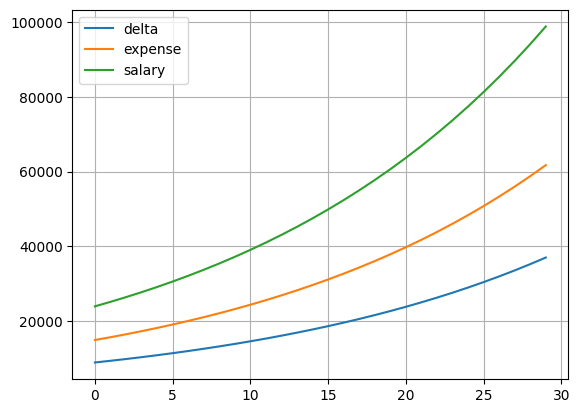

In [88]:
def delta_generator():
  salary = salary_generator(FIRST_YEAR_SALARY, SALARY_GROWING_RATE)
  expense = expense_generator(FIRST_YEAR_EXPENSE, EXPENSE_GROWING_RATE)

  for s, e in itertools.zip_longest(salary, expense):
    yield s - e

df["delta"] = list(itertools.islice(delta_generator(), MAX_YEAR))
df[["delta", "expense", "salary"]].plot().grid()

define asset $x_n$:
$$
\begin{align}
x_{n+1} & = x_{n} (1 + r_{2}) + \delta_{n+1} \\
\delta_{n+1} & = \delta_{n} ( 1 + r_{1}) \\
x_{0} & = 0
\end{align}
$$

In [89]:
def asset_generator(rate):
  x = 0
  delta = delta_generator()
  while True:
    yield x
    x = x * (1 + rate) + next(delta)


df["asset"] = list(itertools.islice(asset_generator(INVESTMENT_RETURN_RATE), MAX_YEAR))
# df.plot()

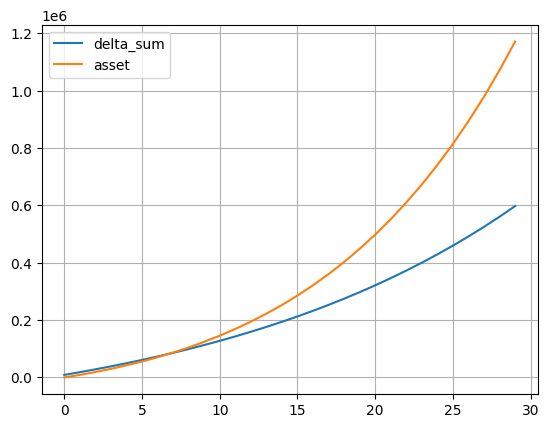

In [90]:
df["delta_sum"] = list(itertools.accumulate(itertools.islice(delta_generator(), MAX_YEAR), ))
df[["delta_sum", "asset"]].plot().grid()

$$
\text{expense coverage} = \frac{x_{n}r_{2}}{\beta_{n+1}}
$$

In [91]:
df["expense_coverage"] = (df["asset"] * INVESTMENT_RETURN_RATE) / df["expense"]
# df["expense_coverage"].plot().grid()

the investment return compared with the next year salary:
$$
\text{income coverage} = \frac{x_{n}r_{2}}{\alpha_{n+1}}
$$

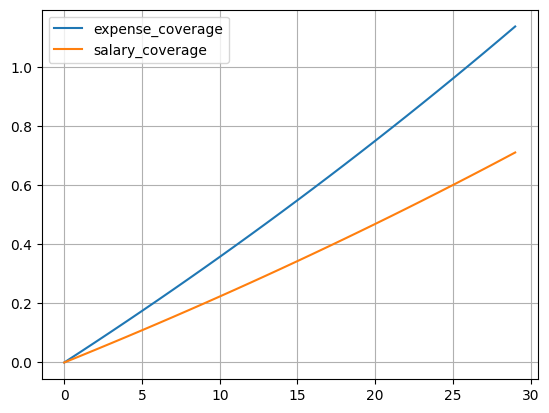

In [92]:
df["salary_coverage"] = (df["asset"] * INVESTMENT_RETURN_RATE) / df["salary"]
df[["expense_coverage", "salary_coverage"]].plot().grid()

In [93]:
class AssetCalculator:
  def __init__(self, first_year_expense, first_year_salary,
                expense_growing_rate, salary_growing_rate,
                investment_return_rate):
    self.first_year_expense = first_year_expense
    self.first_year_salary = first_year_salary
    self.expense_growing_rate = expense_growing_rate
    self.salary_growing_rate = salary_growing_rate
    self.investment_return_rate = investment_return_rate

In [94]:
from ipywidgets import interact
def plot_func(saving_ratio=0.37, first_year_salary=240_000,
                salary_growing_rate=0.05,
                investment_return_rate=0.08, max_year=30):
    # ... update plot based on frequency ...
    FIRST_YEAR_EXPENSE = first_year_salary * (1 - saving_ratio)
    FIRST_YEAR_SALARY = first_year_salary
    EXPENSE_GROWING_RATE = salary_growing_rate
    SALARY_GROWING_RATE = salary_growing_rate
    INVESTMENT_RETURN_RATE = investment_return_rate
    MAX_YEAR = max_year

    df = pd.DataFrame()

    def expense_generator(first_year:float, rate:float) -> Generator[float, None, None]:
      a = first_year
      r = rate
      while True:
        yield a
        a = a * (1 + r)

    salary_generator = expense_generator


    def delta_generator():
      salary = salary_generator(FIRST_YEAR_SALARY, SALARY_GROWING_RATE)
      expense = expense_generator(FIRST_YEAR_EXPENSE, EXPENSE_GROWING_RATE)

      for s, e in itertools.zip_longest(salary, expense):
        yield s - e


    def asset_generator(rate):
      x = 0
      delta = delta_generator()
      while True:
        yield x
        x = x * (1 + rate) + next(delta)


    df["expense"] = list(itertools.islice(expense_generator(FIRST_YEAR_EXPENSE, EXPENSE_GROWING_RATE), MAX_YEAR))
    df["salary"] = list(itertools.islice(salary_generator(FIRST_YEAR_SALARY, SALARY_GROWING_RATE), MAX_YEAR))
    df["delta"] = list(itertools.islice(delta_generator(), MAX_YEAR))
    df["delta_sum"] = list(itertools.accumulate(itertools.islice(delta_generator(), MAX_YEAR), ))
    df["asset"] = list(itertools.islice(asset_generator(INVESTMENT_RETURN_RATE), MAX_YEAR))

    df["expense_coverage"] = (df["asset"] * INVESTMENT_RETURN_RATE) / df["expense"]
    df["salary_coverage"] = (df["asset"] * INVESTMENT_RETURN_RATE) / df["salary"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    ax = df[["expense_coverage", "salary_coverage"]].plot(ax=axes[0])

    ax.set_title("Year to Financial Independence")
    ax.set_xlabel("Year")
    ax.set_ylabel("Money")
    ax.grid()
    ax.set_ylim(0,1)

    ax = df[["asset", "delta_sum"]].plot(ax=axes[1])

    ax.set_title("Investment V.S. Saving")
    ax.set_xlabel("Year")
    ax.set_ylabel("Money")
    ax.grid()

    ax = df[["salary", "expense", "delta"]].plot(ax=axes[2])

    ax.set_title("Balance over Time")
    ax.set_xlabel("Year")
    ax.set_ylabel("Money")
    ax.grid()

    fig.tight_layout()

interact(plot_func,
         saving_ratio=(0, 1, 0.01),
         first_year_salary=(36_000, 500_000, 1_000),
         salary_growing_rate=(0.01, 1, 0.01),
         investment_return_rate=(0.01, 1, 0.01),
         max_year=(20, 40),
);

interactive(children=(FloatSlider(value=0.37, description='saving_ratio', max=1.0, step=0.01), IntSlider(value…